In [8]:
import pandas as pd
import os

pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
os.chdir(pathfile)

# Charger les fichiers CC1 à CC7
cc1 = pd.read_csv(pathcsv + 'CC_1_FA_03022026_AllSubjects.csv')
cc2 = pd.read_csv(pathcsv + 'CC_2_FA_03022026_AllSubjects.csv')
cc3 = pd.read_csv(pathcsv + 'CC_3_FA_03022026_AllSubjects.csv')
cc4 = pd.read_csv(pathcsv + 'CC_4_FA_03022026_AllSubjects.csv')
cc5 = pd.read_csv(pathcsv + 'CC_5_FA_03022026_AllSubjects.csv')
cc6 = pd.read_csv(pathcsv + 'CC_6_FA_03022026_AllSubjects.csv')
cc7 = pd.read_csv(pathcsv + 'CC_7_FA_03022026_AllSubjects.csv')

# Charger les données comportementales
behavior_data = pd.read_csv('Subject_preproc_03022026_AllSubjects.csv')

# Ajouter les données comportementales à chaque CC
for cc in [cc1, cc2, cc3, cc4, cc5, cc6, cc7]:
    cc['sub'] = behavior_data['sub']
    cc['age'] = behavior_data['age']
    cc['JND_P'] = behavior_data['JND_P']
    cc['group'] = behavior_data['group']




In [23]:
import pandas as pd

os.chdir(pathcsv)

# Charger les fichiers CC1 à CC7 et les données comportementales
cc_files = ['CC_1_FA_03022026_AllSubjects.csv', 'CC_2_FA_03022026_AllSubjects.csv',
            'CC_3_FA_03022026_AllSubjects.csv', 'CC_4_FA_03022026_AllSubjects.csv',
            'CC_5_FA_03022026_AllSubjects.csv', 'CC_6_FA_03022026_AllSubjects.csv',
            'CC_7_FA_03022026_AllSubjects.csv']
behavior_data = pd.read_csv('Subject_preproc_03022026_AllSubjects.csv')

# Charger chaque CC et ajouter les données comportementales
cc_data = []
for file in cc_files:
    cc = pd.read_csv(file)
    cc['age'] = behavior_data['age']
    cc['JND_P'] = behavior_data['JND_P']
    cc_data.append(cc)

# Fonction pour calculer les corrélations
def get_top_correlations(cc, target, n=10):
    corr = cc.iloc[:, :98].corrwith(cc[target]).sort_values(ascending=False)
    return corr.head(n), corr.tail(n)

# Analyser chaque CC
for i, cc in enumerate(cc_data, 1):
    print(f"\n--- CC{i} ---")
    top_age_pos, top_age_neg = get_top_correlations(cc, 'age')
    top_jnd_pos, top_jnd_neg = get_top_correlations(cc, 'JND_P')

    print("\nTop 5 segments corrélés positivement avec l'âge :")
    print(top_age_pos)
    print("\nTop 5 segments corrélés négativement avec l'âge :")
    print(top_age_neg)

    print("\nTop 5 segments corrélés positivement avec le JND :")
    print(top_jnd_pos)
    print("\nTop 5 segments corrélés négativement avec le JND :")
    print(top_jnd_neg)



--- CC1 ---

Top 5 segments corrélés positivement avec l'âge :
48   -0.217228
47   -0.221035
46   -0.239818
45   -0.260373
44   -0.314194
49   -0.314288
43   -0.348531
97   -0.360462
96   -0.362458
95   -0.369031
dtype: float64

Top 5 segments corrélés négativement avec l'âge :
19   -0.712444
84   -0.713811
11   -0.716976
18   -0.729828
12   -0.734726
13   -0.743354
17   -0.744607
14   -0.750985
16   -0.752226
15   -0.753752
dtype: float64

Top 5 segments corrélés positivement avec le JND :
65   -0.254485
64   -0.265713
48   -0.278524
47   -0.289490
66   -0.290005
0    -0.317982
45   -0.326576
46   -0.336731
42   -0.342696
43   -0.350201
dtype: float64

Top 5 segments corrélés négativement avec le JND :
82   -0.567365
83   -0.569811
77   -0.575682
87   -0.577152
84   -0.580456
74   -0.580485
75   -0.583223
85   -0.584166
86   -0.589509
76   -0.589873
dtype: float64

--- CC2 ---

Top 5 segments corrélés positivement avec l'âge :
47   -0.534723
96   -0.555862
2    -0.557353
0    -0.5611

In [24]:
def select_features(cc, target, threshold=0.5):
    corr = cc.iloc[:, :98].corrwith(cc[target])
    return corr[abs(corr) > threshold].index.tolist()

# Sélectionner les features pour chaque CC et chaque cible
results = []
for i, cc in enumerate(cc_data, 1):
    features_age = select_features(cc, 'age')
    features_jnd = select_features(cc, 'JND_P')

    X_age = cc[features_age]
    y_age = cc['age']
    X_jnd = cc[features_jnd]
    y_jnd = cc['JND_P']


In [25]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def evaluate_models(X, y):
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(random_state=42),
        'SVM': make_pipeline(StandardScaler(), SVR(kernel='rbf'))
    }
    scores = {}
    for name, model in models.items():
        cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
        scores[name] = cv_scores.mean()
    return scores

# Évaluer les modèles pour chaque CC et chaque cible
for i, cc in enumerate(cc_data, 1):
    features_age = select_features(cc, 'age', threshold=0.4)
    features_jnd = select_features(cc, 'JND_P', threshold=0.4)

    if features_age and features_jnd:
        X_age = cc[features_age]
        y_age = cc['age']
        X_jnd = cc[features_jnd]
        y_jnd = cc['JND_P']

        age_scores = evaluate_models(X_age, y_age)
        jnd_scores = evaluate_models(X_jnd, y_jnd)

        print(f"\n--- CC{i} ---")
        print("Prédiction de l'âge :", age_scores)
        print("Prédiction du JND :", jnd_scores)



--- CC1 ---
Prédiction de l'âge : {'Linear Regression': -0.8932250036540615, 'Random Forest': 0.5647118165490255, 'SVM': -0.23148028130248535}
Prédiction du JND : {'Linear Regression': -7.013865599533803, 'Random Forest': -0.11416913364294871, 'SVM': -0.051498439081393975}

--- CC2 ---
Prédiction de l'âge : {'Linear Regression': -1.1320139319995675, 'Random Forest': 0.45381642524120147, 'SVM': -0.1544204330320322}
Prédiction du JND : {'Linear Regression': -1.6787054590640231, 'Random Forest': 0.05808057016123251, 'SVM': 0.07223309014713311}

--- CC3 ---
Prédiction de l'âge : {'Linear Regression': -0.29686538453421357, 'Random Forest': 0.22619025109145613, 'SVM': -0.4503909156817308}
Prédiction du JND : {'Linear Regression': -0.38804197889521463, 'Random Forest': 0.027260853357115346, 'SVM': 0.08594683110714377}

--- CC4 ---
Prédiction de l'âge : {'Linear Regression': -0.886422010515018, 'Random Forest': 0.36612556801246293, 'SVM': -0.41965372434512194}
Prédiction du JND : {'Linear Reg

In [22]:
# Optimisation pour un CC donné (exemple : CC1)
param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 10]}
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='r2')
grid_search.fit(X_age, y_age)
print("Meilleurs paramètres pour l'âge (CC1) :", grid_search.best_params_)


Meilleurs paramètres pour l'âge (CC1) : {'max_depth': None, 'n_estimators': 50}


In [26]:
# Comparer les R² moyens pour chaque CC et chaque cible
for i, cc in enumerate(cc_data, 1):
    features_age = select_features(cc, 'age', threshold=0.4)
    features_jnd = select_features(cc, 'JND_P', threshold=0.4)

    if features_age and features_jnd:
        X_age = cc[features_age]
        y_age = cc['age']
        X_jnd = cc[features_jnd]
        y_jnd = cc['JND_P']

        age_r2 = evaluate_models(X_age, y_age)['Random Forest']
        jnd_r2 = evaluate_models(X_jnd, y_jnd)['Random Forest']

        print(f"\nCC{i} : Age R² = {age_r2:.3f}, JND R² = {jnd_r2:.3f}")
        print("L'âge est mieux prédit" if age_r2 > jnd_r2 else "Le JND est mieux prédit")



CC1 : Age R² = 0.565, JND R² = -0.114
L'âge est mieux prédit

CC2 : Age R² = 0.454, JND R² = 0.058
L'âge est mieux prédit

CC3 : Age R² = 0.226, JND R² = 0.027
L'âge est mieux prédit

CC4 : Age R² = 0.366, JND R² = -0.009
L'âge est mieux prédit

CC5 : Age R² = 0.275, JND R² = -0.244
L'âge est mieux prédit

CC6 : Age R² = 0.502, JND R² = 0.008
L'âge est mieux prédit

CC7 : Age R² = 0.088, JND R² = -0.083
L'âge est mieux prédit


In [ ]:
def select_features(cc, target, threshold=0.4):
    corr = cc.iloc[:, :98].corrwith(cc[target])
    return corr[abs(corr) > threshold].index.tolist()

def evaluate_models(X, y):
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(random_state=42),
        'SVM': make_pipeline(StandardScaler(), SVR(kernel='rbf'))
    }
    scores = {}
    for name, model in models.items():
        cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
        scores[name] = np.mean(cv_scores)
    return scores

# Stocker les résultats pour chaque CC
cc_results = []
for i, cc in enumerate(cc_data, 1):
    features_age = select_features(cc, 'age')
    features_jnd = select_features(cc, 'JND_P')

    if features_age and features_jnd:
        X_age = cc[features_age]
        y_age = cc['age']
        X_jnd = cc[features_jnd]
        y_jnd = cc['JND_P']

        age_scores = evaluate_models(X_age, y_age)
        jnd_scores = evaluate_models(X_jnd, y_jnd)

        cc_results.append({
            'CC': f'CC{i}',
            'Age_R2': age_scores,
            'JND_R2': jnd_scores
        })



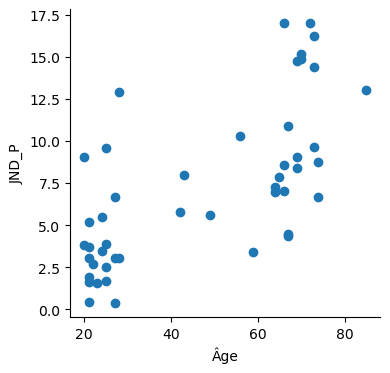

In [41]:
cc_data[ccid-1].iloc[:, :98].corrwith(cc_data[ccid-1 ]['JND_P'])

fig, ax = plt.subplots(figsize=(4,4))
ax.scatter(cc_data[ccid-1]['age'], cc_data[ccid-1]['JND_P'])
ax.set_xlabel('Âge')
ax.set_ylabel('JND_P')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



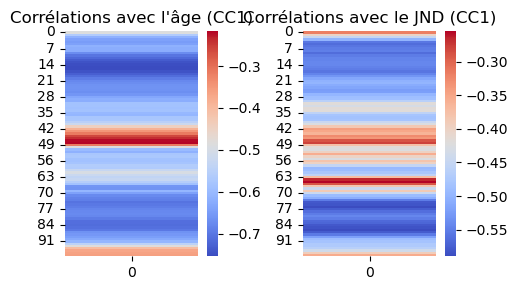

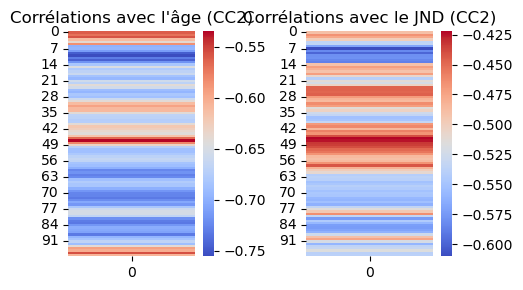

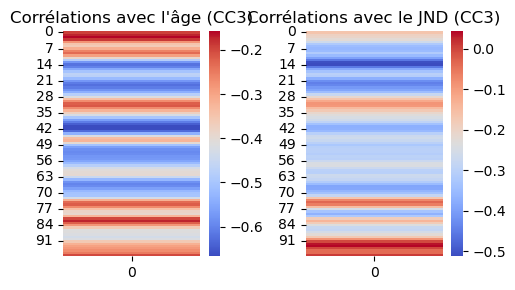

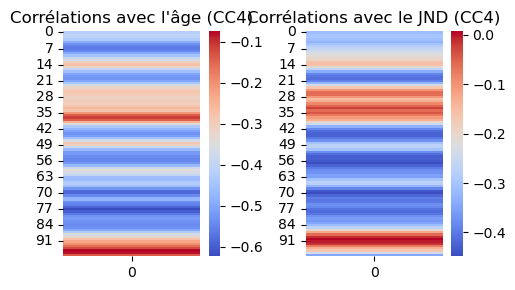

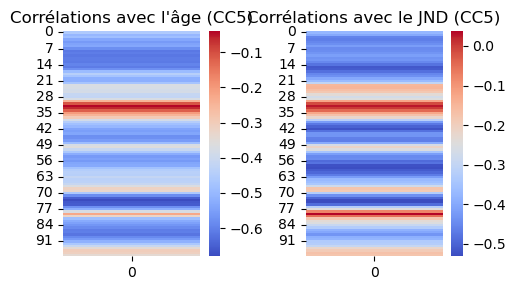

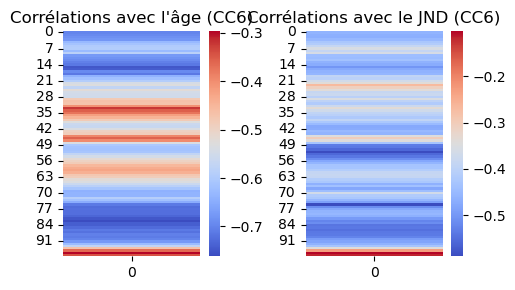

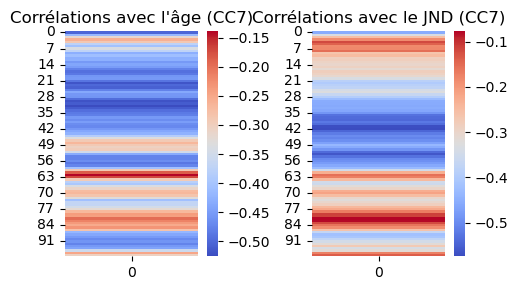

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

for ccid in range(1, 8):
 
    cc_corr_age = cc_data[ccid-1].iloc[:, :98].corrwith(cc_data[ccid-1]['age'])
    cc_corr_jnd = cc_data[ccid-1].iloc[:, :98].corrwith(cc_data[ccid-1 ]['JND_P'])

    plt.figure(figsize=(5,3))
    plt.subplot(1, 2, 1)
    sns.heatmap(cc_corr_age.to_frame(), annot=False, cmap='coolwarm', cbar=True)
    plt.title(f"Corrélations avec l'âge (CC{ccid})")

    plt.subplot(1, 2, 2)
    sns.heatmap(cc_corr_jnd.to_frame(), annot=False, cmap='coolwarm', cbar=True)
    plt.title(f"Corrélations avec le JND (CC{ccid})")
    plt.tight_layout()
    plt.show()


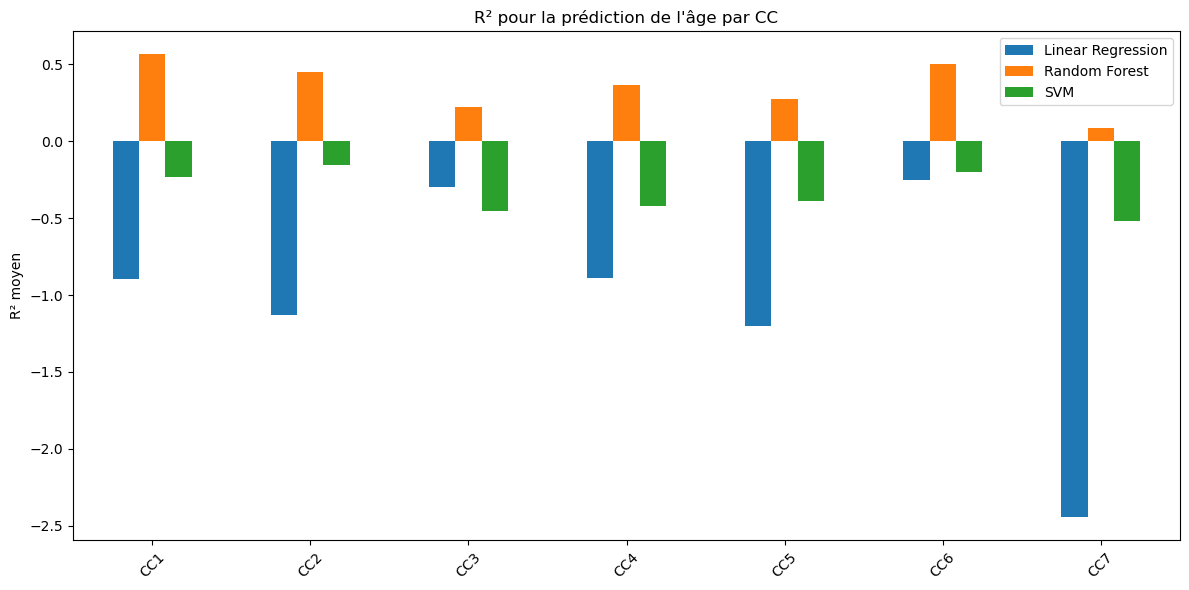

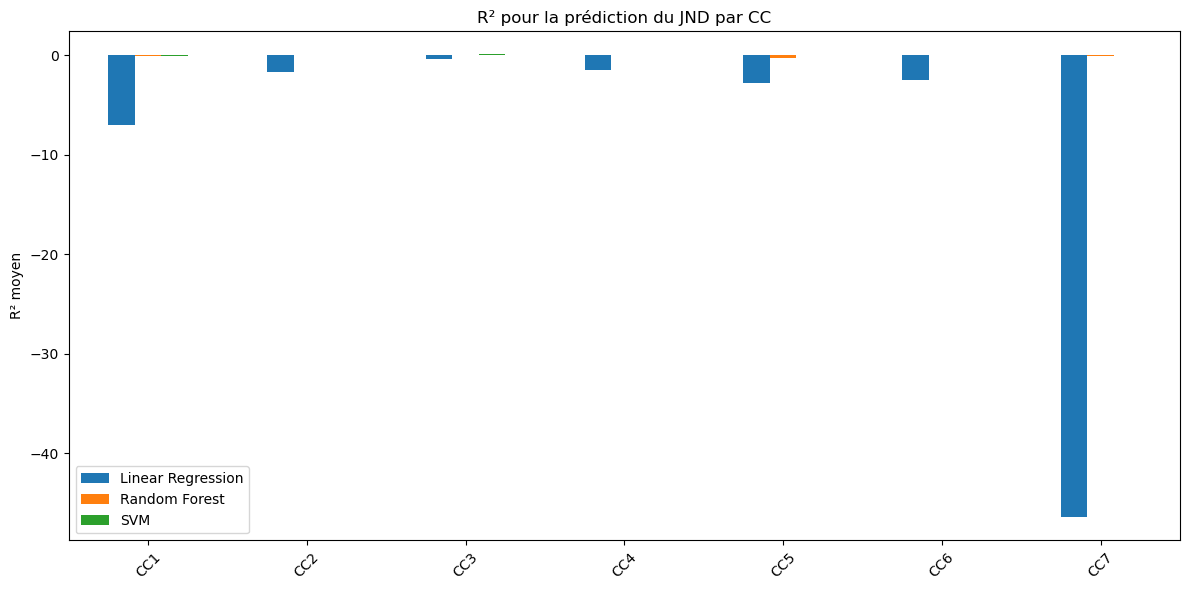

In [32]:
# Préparer les données pour le barplot
model_names = list(cc_results[0]['Age_R2'].keys())
age_r2 = [result['Age_R2'] for result in cc_results]
jnd_r2 = [result['JND_R2'] for result in cc_results]

age_df = pd.DataFrame(age_r2, index=[f"CC{i+1}" for i in range(len(age_r2))])
jnd_df = pd.DataFrame(jnd_r2, index=[f"CC{i+1}" for i in range(len(jnd_r2))])

# Tracer les barplots
age_df.plot(kind='bar', figsize=(12, 6))
plt.title("R² pour la prédiction de l'âge par CC")
plt.ylabel("R² moyen")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

jnd_df.plot(kind='bar', figsize=(12, 6))
plt.title("R² pour la prédiction du JND par CC")
plt.ylabel("R² moyen")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
